# Data Cleaning and Preprocessing :

In [2]:
import pandas as pd
import numpy as np
gd = pd.read_csv("Steam_Games.csv")

In [3]:
gd.head()

,Title,Release_Date,Price,Reviews,Discount,Game_Link,Genres
0,Forza Horizon 6,"18 May, 2026","₹5,499.00","Very Positive : 86% of the 13,226 user reviews...",0%,https://store.steampowered.com/app/2483190/For...,"Racing, Simulation, Sports"
1,Counter-Strike 2,"21 Aug, 2012",Free,"Very Positive : 86% of the 2,539,502 user revi...",0%,https://store.steampowered.com/app/730/Counter...,"Action, Free To Play"
2,Subnautica 2,"14 May, 2026","₹1,800.00","Very Positive : 93% of the 41,688 user reviews...",0%,https://store.steampowered.com/app/1962700/Sub...,"Action, Adventure, Early Access"
3,LEGO® Batman™: Legacy of the Dark Knight,"22 May, 2026","₹3,899.00",Overwhelmingly Positive : 95% of the 799 user ...,0%,https://store.steampowered.com/app/2215200/LEG...,"Action, Adventure"
4,Warframe,"25 Mar, 2013",Free,"Very Positive : 91% of the 293,180 user review...",0%,https://store.steampowered.com/app/230410/Warf...,"Action, RPG, Free To Play"


In [4]:
gd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         1000 non-null   object
 1   Release_Date  1000 non-null   object
 2   Price         1000 non-null   object
 3   Reviews       991 non-null    object
 4   Discount      1000 non-null   object
 5   Game_Link     1000 non-null   object
 6   Genres        873 non-null    object
dtypes: object(7)
memory usage: 54.8+ KB


### <> Handling missing values <>

In [5]:
# Checking the dataset for missing values.
gd.isnull().sum()

Title             0
Release_Date      0
Price             0
Reviews           9
Discount          0
Game_Link         0
Genres          127
dtype: int64

In [6]:
# Replacing the duplicates values in Genres column with "Unknown".
gd["Genres"] = gd["Genres"].fillna("Unknown")

### <> Removing duplicate values <>

In [7]:
# Checking for duplicate entries.
gd.duplicated().sum()

np.int64(0)

### <> Cleaning the Price, Discount, Release Date and Review <>.

In [8]:
# Cleaning the Price column and converting it into numeric format.
gd["Price"] = (gd["Price"].astype(str).str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False).str.replace("Free", "0", regex=False)
    .str.strip())
gd["Price"] = pd.to_numeric(gd["Price"], errors="coerce")
# Cleaning the Discount column and converting it into numeric format.
gd["Discount"] = (gd["Discount"].astype(str).str.replace("%", "", regex=False)
    .str.replace("-", "", regex=False))
gd["Discount"] = pd.to_numeric(gd["Discount"],errors="coerce")
# Converting Release Date into proper datetime format.
gd['Release_Date'] = gd['Release_Date'].str.strip()
gd['Release_Date'] = pd.to_datetime(
    gd['Release_Date'],
    format='%d %b, %Y',
    errors='coerce')
# Cleaning the Reveiws column.
gd["Reviews"] = (gd["Reviews"].str.split(":").str[0].str.strip())
gd["Reviews"] = (gd["Reviews"].astype(str).str.strip())
print(gd["Price"])
print(gd["Discount"])
print(gd["Release_Date"])
print(gd["Reviews"])

0      5499.0
1         0.0
2      1800.0
3      3899.0
4         0.0
        ...  
995     810.0
996     349.0
997       0.0
998     449.0
999     769.0
Name: Price, Length: 1000, dtype: float64
0       0
1       0
2       0
3       0
4       0
       ..
995     0
996     0
997     0
998    85
999     0
Name: Discount, Length: 1000, dtype: int64
0     2026-05-18
1     2012-08-21
2     2026-05-14
3     2026-05-22
4     2013-03-25
         ...    
995   2026-03-06
996   2019-07-23
997   2017-07-07
998   2023-01-26
999   2015-09-01
Name: Release_Date, Length: 1000, dtype: datetime64[ns]
0                Very Positive
1                Very Positive
2                Very Positive
3      Overwhelmingly Positive
4                Very Positive
                ...           
995    Overwhelmingly Positive
996    Overwhelmingly Positive
997              Very Positive
998                      Mixed
999              Very Positive
Name: Reviews, Length: 1000, dtype: object


### <> Feature Engineering <>

In [9]:
# Creating Review score.
review_map = {"Overwhelmingly Positive": 100, "Very Positive": 85, 
              "Positive": 75, "Mostly Positive": 65, "Mixed": 50, 
              "Mostly Negative": 35, "Negative": 20, "Very Negative": 10}
gd["Review_Score"] = (gd["Reviews"].map(review_map))
# Extracting Year and Month from Release Date.
gd["Release_Year"] = (gd["Release_Date"].dt.year)
gd["Release_Month"] = (gd["Release_Date"].dt.month_name())
# Creating a Price category as Free or Paid and a Discount category.
gd["Game_Type"] = np.where(gd["Price"] == 0, "Free", "Paid")
gd["Discount_Level"] = pd.cut(gd["Discount"], bins=[-1, 0, 25, 50, 75, 100], labels=[
    "No Discount","Low","Medium","High","Huge"])
# Counting the total no of Genres.
gd["Genre_Count"] = (gd["Genres"].astype(str).apply(lambda x: len(x.split(","))))

In [10]:
gd.head()

,Title,Release_Date,Price,Reviews,Discount,Game_Link,Genres,Review_Score,Release_Year,Release_Month,Game_Type,Discount_Level,Genre_Count
0,Forza Horizon 6,2026-05-18,5499.0,Very Positive,0,https://store.steampowered.com/app/2483190/For...,"Racing, Simulation, Sports",85.0,2026,May,Paid,No Discount,3
1,Counter-Strike 2,2012-08-21,0.0,Very Positive,0,https://store.steampowered.com/app/730/Counter...,"Action, Free To Play",85.0,2012,August,Free,No Discount,2
2,Subnautica 2,2026-05-14,1800.0,Very Positive,0,https://store.steampowered.com/app/1962700/Sub...,"Action, Adventure, Early Access",85.0,2026,May,Paid,No Discount,3
3,LEGO® Batman™: Legacy of the Dark Knight,2026-05-22,3899.0,Overwhelmingly Positive,0,https://store.steampowered.com/app/2215200/LEG...,"Action, Adventure",100.0,2026,May,Paid,No Discount,2
4,Warframe,2013-03-25,0.0,Very Positive,0,https://store.steampowered.com/app/230410/Warf...,"Action, RPG, Free To Play",85.0,2013,March,Free,No Discount,3


In [11]:
gd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Title           1000 non-null   object        
 1   Release_Date    1000 non-null   datetime64[ns]
 2   Price           1000 non-null   float64       
 3   Reviews         1000 non-null   object        
 4   Discount        1000 non-null   int64         
 5   Game_Link       1000 non-null   object        
 6   Genres          1000 non-null   object        
 7   Review_Score    991 non-null    float64       
 8   Release_Year    1000 non-null   int32         
 9   Release_Month   1000 non-null   object        
 10  Game_Type       1000 non-null   object        
 11  Discount_Level  1000 non-null   category      
 12  Genre_Count     1000 non-null   int64         
dtypes: category(1), datetime64[ns](1), float64(2), int32(1), int64(2), object(6)
memory usage: 91.2+ KB


In [12]:
gd.describe()

,Release_Date,Price,Discount,Review_Score,Release_Year,Genre_Count
count,1000,1000.000000,1000.000000,991.000000,1000.000000,1000.000000
mean,2022-07-30 04:24:57.600000,1266.083000,9.750000,79.344097,2022.101000,2.669000
min,2006-11-30 00:00:00,0.000000,0.000000,20.000000,2006.000000,1.000000
25%,2020-04-30 00:00:00,431.750000,0.000000,65.000000,2020.000000,1.000000
50%,2024-04-02 00:00:00,899.000000,0.000000,85.000000,2024.000000,2.000000
75%,2025-10-28 00:00:00,1781.000000,0.000000,85.000000,2025.000000,4.000000
max,2026-07-10 00:00:00,5999.000000,92.000000,100.000000,2026.000000,8.000000
std,NaN,1165.058799,22.010178,16.005796,4.133508,1.486489


# EDA and Visualizations :

In [13]:
import matplotlib.pyplot as plt
import seaborn as sb

### <> Getting the Statistical Summary and distribution of Numerical features <>

In [14]:
gd[["Price", "Discount", "Review_Score"]].describe()

,Price,Discount,Review_Score
count,1000.000000,1000.000000,991.000000
mean,1266.083000,9.750000,79.344097
std,1165.058799,22.010178,16.005796
min,0.000000,0.000000,20.000000
25%,431.750000,0.000000,65.000000
50%,899.000000,0.000000,85.000000
75%,1781.000000,0.000000,85.000000
max,5999.000000,92.000000,100.000000


### <> Visualizations <>

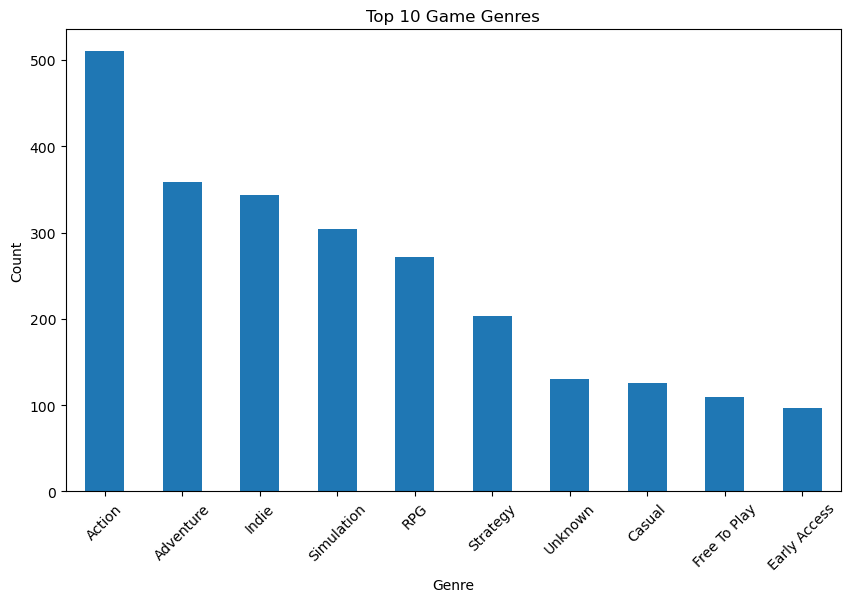

In [15]:
# Bar chart to get the top 10 Genres.
genre_counts = (
    gd["Genres"].str.split(", ").explode()
        .value_counts().head(10))
plt.figure(figsize=(10,6))
genre_counts.plot(kind="bar")
plt.title("Top 10 Game Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

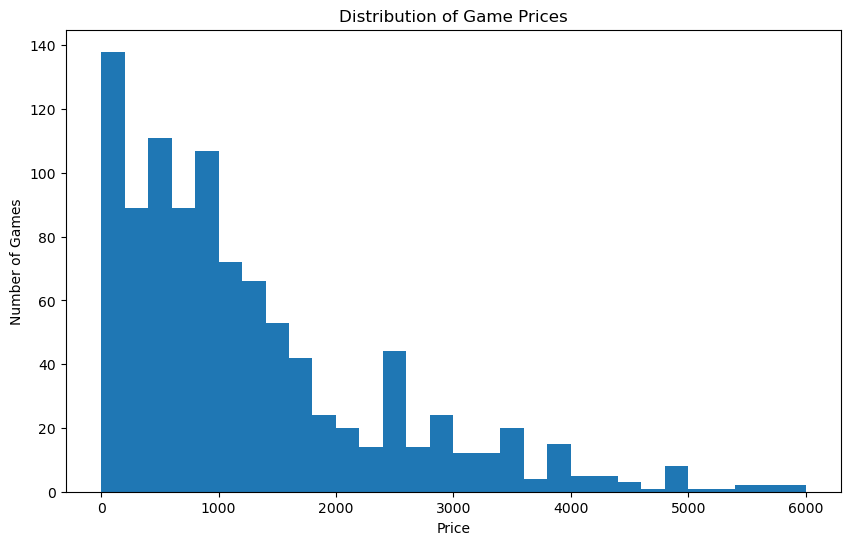

In [16]:
# Histogran to understand the Price distribution.
plt.figure(figsize=(10,6))
plt.hist(gd["Price"].dropna(),bins=30)
plt.title("Distribution of Game Prices")
plt.xlabel("Price")
plt.ylabel("Number of Games")
plt.show()

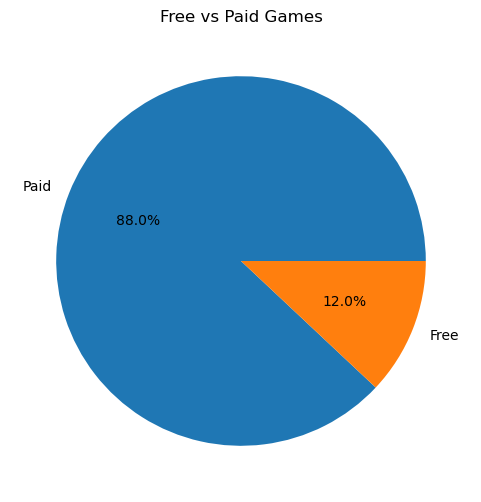

In [17]:
# Pie chart for Free vs Paid games.
game_type_counts = (gd["Game_Type"].value_counts())
plt.figure(figsize=(6,6))
plt.pie(game_type_counts,labels=game_type_counts.index,
        autopct="%1.1f%%")
plt.title("Free vs Paid Games")
plt.show()

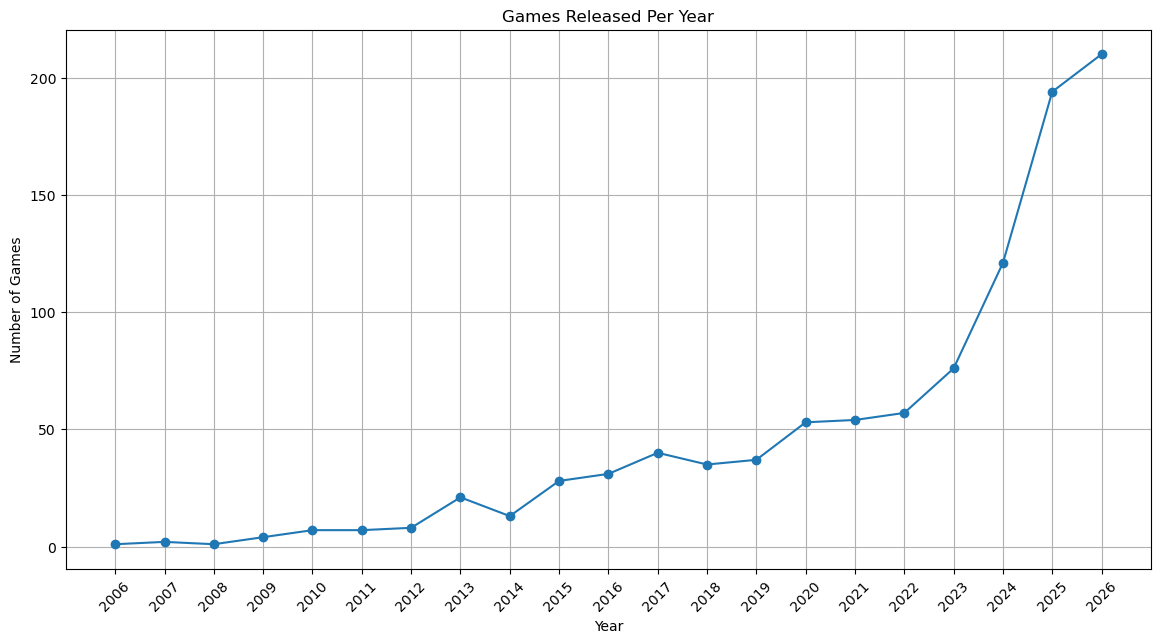

In [18]:
# Line chart for Yearly Release Trend Analysis.
year_counts = (gd["Release_Year"].value_counts().sort_index())
plt.figure(figsize=(14,7))
plt.plot(year_counts.index,year_counts.values, marker="o")
plt.xticks(range(int(gd['Release_Year'].min()), int(gd['Release_Year'].max()) + 1),
           rotation=45)
plt.title("Games Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Games")
plt.grid(True)
plt.show()

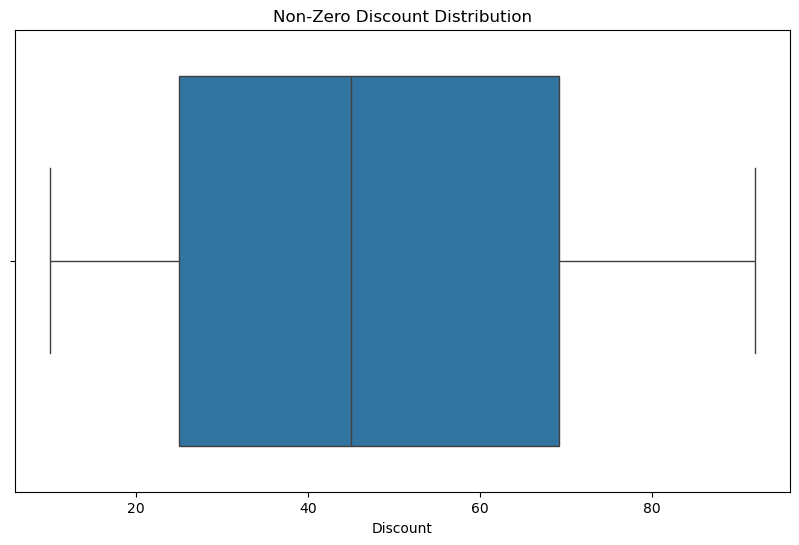

In [19]:
# Boxplot for Non-zero Discount Analysis and Outlier detection.
active_disc = gd[gd["Discount"]>0]
plt.figure(figsize=(10,6))
sb.boxplot(x=active_disc["Discount"])
plt.title("Non-Zero Discount Distribution")
plt.show()

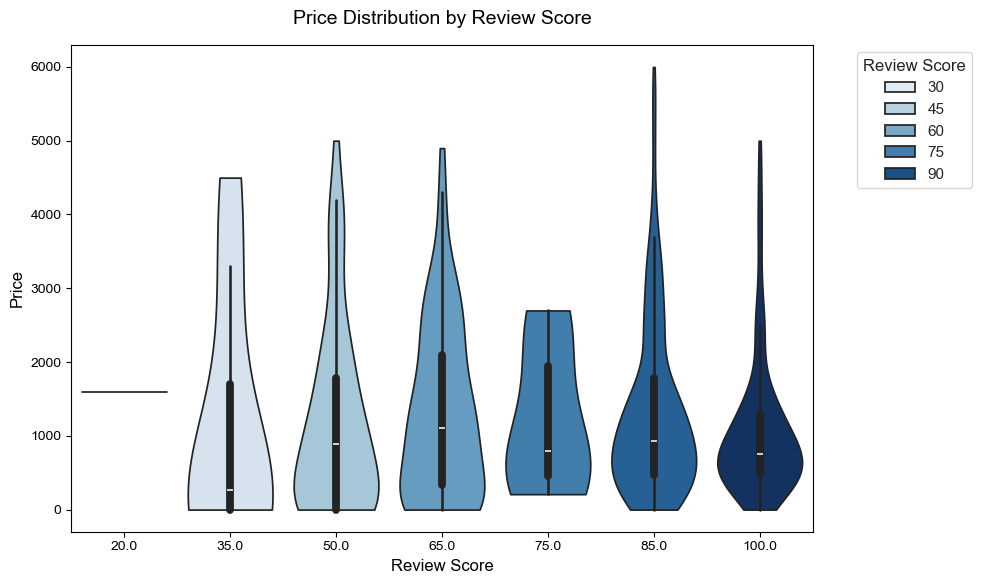

In [20]:
# Violin plot to understand the Price distribution for each Review Score.
fig, ax = plt.subplots(figsize=(10, 6))
sb.set_theme(style="whitegrid")
ax = sb.violinplot(data=gd,x="Review_Score",y="Price",
    inner="box",cut=0,palette="Blues",hue="Review_Score",ax=ax)
sb.move_legend(ax, "upper left", bbox_to_anchor=(1.05, 1), title="Review Score")
ax.set_title("Price Distribution by Review Score", fontsize=14, pad=15)
ax.set_xlabel("Review Score", fontsize=12)
ax.set_ylabel("Price", fontsize=12)
plt.tight_layout()
plt.show()

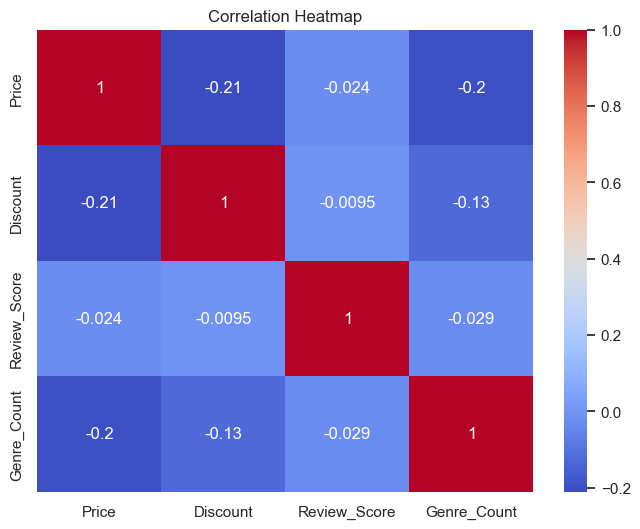

In [21]:
# Generating Heatmap to get the Correlation Matrix between the Numerical columns.
num_gd = gd[["Price","Discount","Review_Score","Genre_Count"]]
plt.figure(figsize=(8,6))
sb.heatmap(num_gd.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

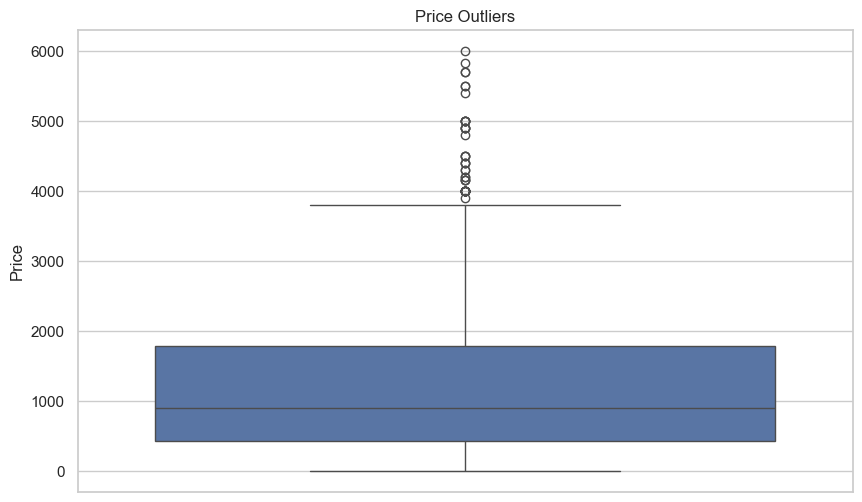

In [22]:
# Boxplot to identify the outliers in Price column.
plt.figure(figsize=(10,6))
sb.boxplot(y=gd["Price"])
plt.title("Price Outliers")
plt.show()

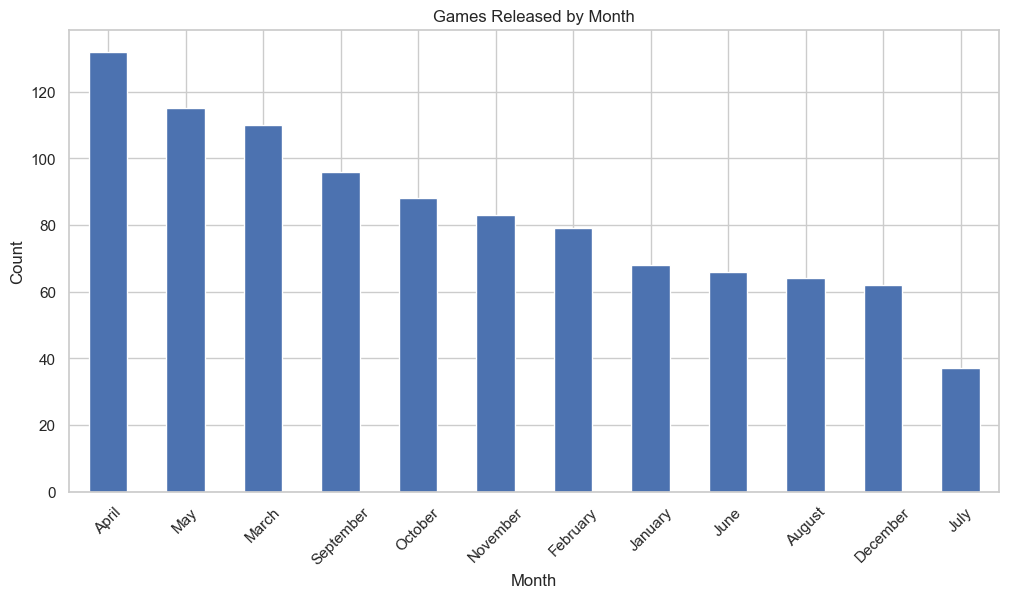

In [23]:
# Bar plot to get the Monthly Release Trend.
month_counts = (gd["Release_Month"].value_counts())
plt.figure(figsize=(12,6))
month_counts.plot(kind="bar")
plt.title("Games Released by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

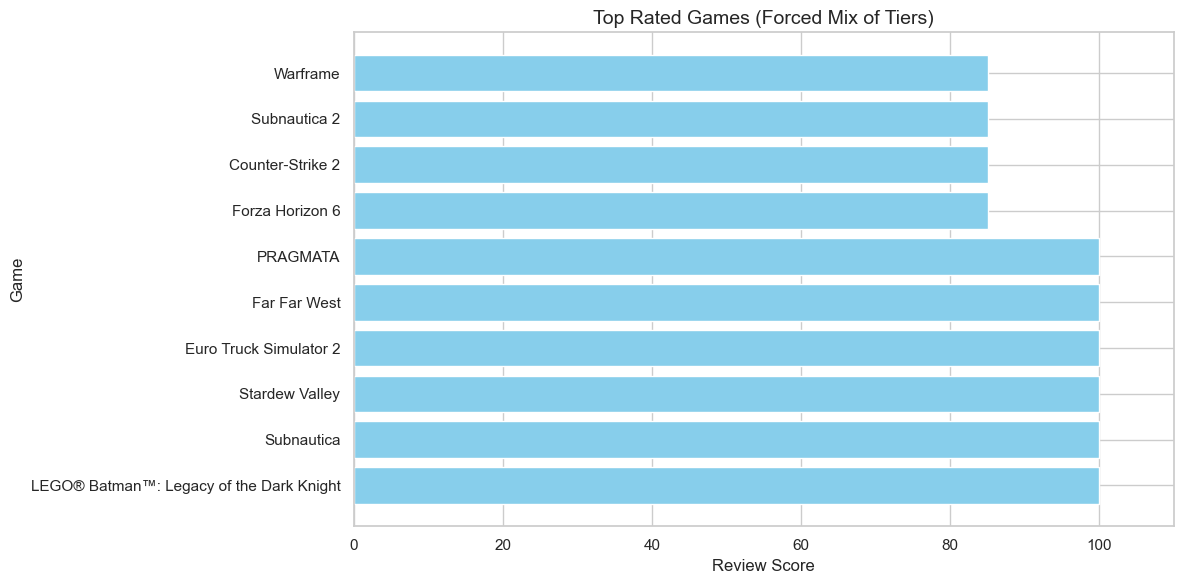

In [24]:
# Identifying the Top Rated/Reviewed by the top 2 tiers of Review Score using 
# a Horizontal Bar Chart.
top_tier = gd[gd["Review_Score"] == 100]
second_tier = gd[gd["Review_Score"] == 85]
sampled_top = top_tier.head(6)
sampled_second = second_tier.head(4)
top_games = pd.concat([sampled_top, sampled_second])
top_games = top_games.sort_values(by="Review_Score", ascending=False)
plt.figure(figsize=(12, 6))
plt.barh(top_games["Title"], top_games["Review_Score"], color="skyblue")
plt.title("Top Rated Games (Forced Mix of Tiers)", fontsize=14)
plt.xlabel("Review Score", fontsize=12)
plt.ylabel("Game", fontsize=12)
plt.xlim(0, 110)
plt.tight_layout()
plt.show()

# Model Building & Evaluation.

### <> Building a K-Means Clustering Model to group games based on relevant features <>

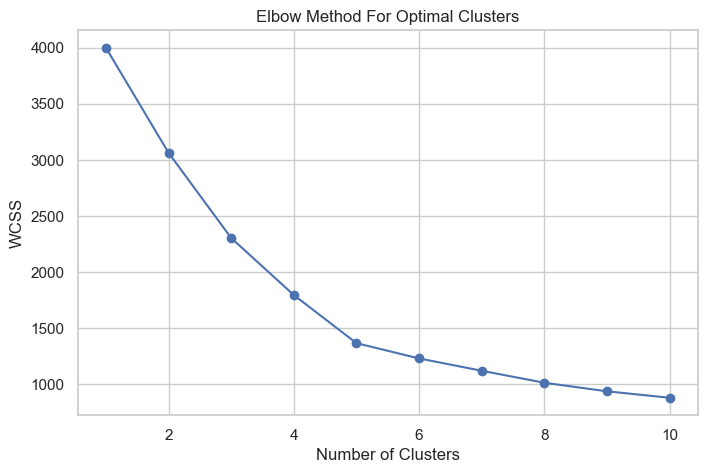

In [25]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# Selecting the features.
features = ["Price","Discount",
            "Genre_Count","Release_Year"]
X = gd[features]
# Handling missing values.
X = X.fillna(X.mean())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Using the Elbow Method to find the optimal value of K.
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, 
                    n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
# Generating the Elbow Graph.    
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method For Optimal Clusters")
plt.grid(True)
plt.show()

                                      Title  Cluster          Cluster_Name
0                           Forza Horizon 6        3     Premium AAA Games
1                          Counter-Strike 2        1    Budget Indie Games
2                              Subnautica 2        2  Diverse Modern Games
3  LEGO® Batman™: Legacy of the Dark Knight        3     Premium AAA Games
4                                  Warframe        1    Budget Indie Games
5                       PUBG: BATTLEGROUNDS        2  Diverse Modern Games
6                             Apex Legends™        1    Budget Indie Games
7                                Subnautica        0  Old Discounted Games
8                     Red Dead Redemption 2        0  Old Discounted Games
9                            Crimson Desert        3     Premium AAA Games


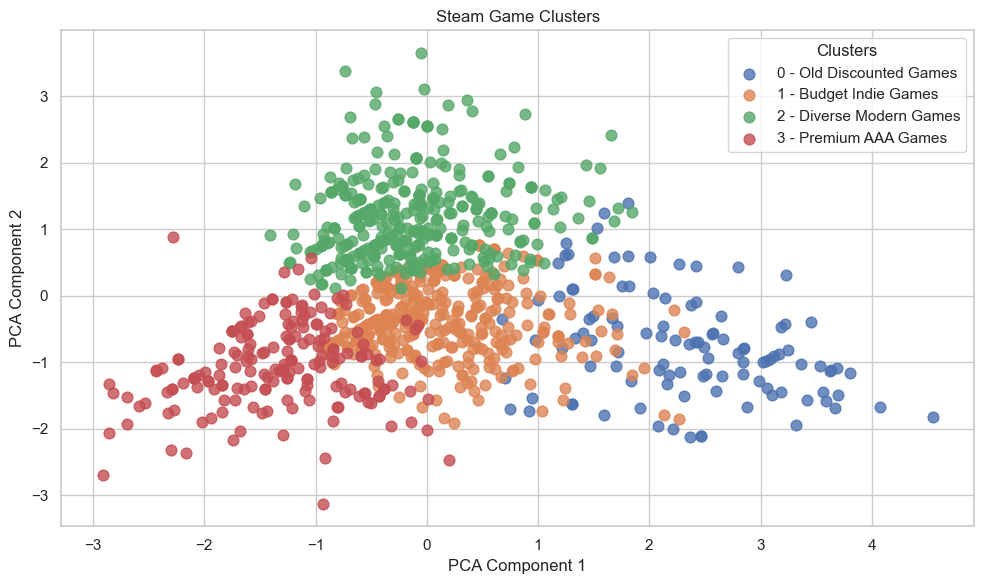


Cluster Counts:

Cluster
1    356
2    350
3    187
0    107
Name: count, dtype: int64

Cluster Summary:

               Price   Discount  Genre_Count  Release_Year
Cluster                                                   
0         614.205607  66.943925     2.037383   2019.289720
1         895.994382   2.497191     1.640449   2021.199438
2         773.322857   3.728571     4.222857   2023.262857
3        3265.914439   2.101604     2.080214   2023.251337


In [26]:
# Developing the K-Means Model.
kmeans = KMeans(n_clusters=4, 
                random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
# Adding Clusters to the DataFrame.
gd["Cluster"] = clusters
# Implementing PCA 2D Visuals.
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_scaled)
# Interpreting and adding the accurate label to each cluster.
cluster_names = {0: "Old Discounted Games",1: "Budget Indie Games", 
                 2: "Diverse Modern Games", 3: "Premium AAA Games"}
# Mapping the labels.
gd["Cluster_Name"] = gd["Cluster"].map(cluster_names)
print(gd[["Title", "Cluster", "Cluster_Name"]].head(10))
# Visualizing the Clusters.
# Create figure
plt.figure(figsize=(10,6))
# Plotting clusters.
for cluster in sorted(gd["Cluster"].unique()):
    plt.scatter(pca_features[gd["Cluster"] == cluster, 0], 
                pca_features[gd["Cluster"] == cluster, 1], 
                label=f"{cluster} - {cluster_names[cluster]}",
                s=60, alpha=0.8)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Steam Game Clusters")
plt.legend(title="Clusters")
plt.grid(True)
plt.tight_layout()
plt.show()
# Displaying Cluster Summary. 
print("\nCluster Counts:\n")
print(gd["Cluster"].value_counts())
# Average values per Cluster.
cluster_summary = gd.groupby("Cluster")[features].mean()
print("\nCluster Summary:\n")
print(cluster_summary)

### <> Implementing a Classification Model (RandomForestClassifier) to predict 
### Popular vs Non-popular games <>

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV  
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Creating Target variable based on Review_Score.
gd["Popular"] = np.where(gd["Review_Score"] >= 80, 1, 0)
# Setting features and target variable.
features = ["Price", "Discount", "Genre_Count", "Release_Year"]
X = gd[features].copy()
y = gd["Popular"]
# Handling missing values.
for col in X.columns:
    X[col] = X[col].fillna(X[col].median())
# Splitting the Training and Testing data.
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,
                                                    random_state=42, stratify=y)
# Defining the Parameter Grid to search through.
param_grid = {'n_estimators': [50, 100, 200],
              'max_depth': [3, 5, 7, None],
              'min_samples_split': [2, 5, 10]}
# Initializing Grid Search with Cross-Validation, it splits the training data 5 ways 
# to validate choices.
rf_base = RandomForestClassifier(random_state=42, class_weight="balanced")
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
# Run the search on training data.
grid_search.fit(X_train, y_train)
# Print out the absolute best combination discovered.
print("Best Parameters Found:", grid_search.best_params_)
# Using the best discovered model to make predictions.
best_classifier = grid_search.best_estimator_
y_pred = best_classifier.predict(X_test)
# Model Evaluation.
accuracy = accuracy_score(y_test, y_pred)
print("\nOptimized Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))
# Visualizing the Confusion Matrix.
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sb.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Optimized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Saving the final dataset as a .csv file, so that it can be imported into Power BI in
# order to build the Dashboard.
gd.to_csv("SteamVision_final.csv", index=False)